# Explore generated samples

C:\Users\truok\AppData\Local\Temp\ipykernel_25196\2348245225.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm').copy()


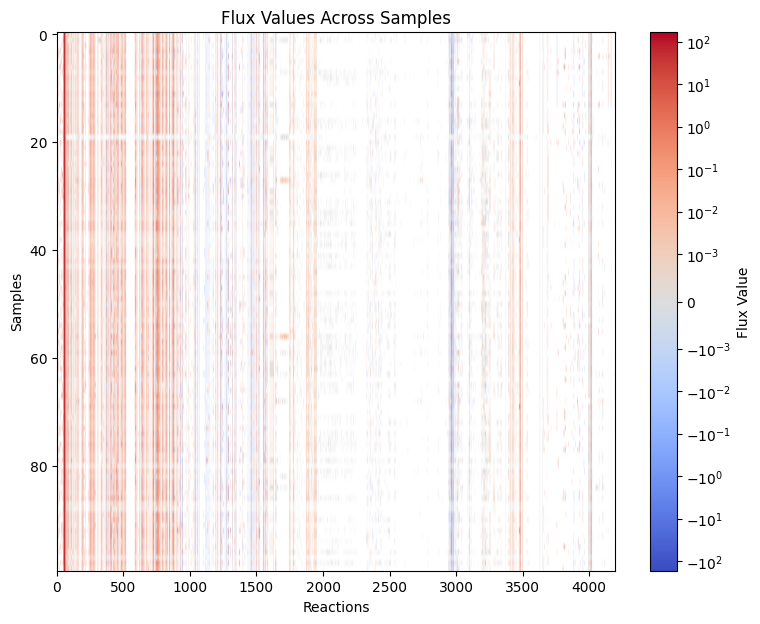

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from matplotlib.colors import SymLogNorm
from matplotlib import cm
from yeast9_reactions import inputs, outputs

DATA_PATH = './data/2025-11-10_yeast9_data_100_samples.csv'

matrix = np.loadtxt(DATA_PATH, delimiter=',', skiprows=1)

plt.figure(figsize=(9, 7))
plt.title("Flux Values Across Samples")
plt.xlabel("Reactions")
plt.ylabel("Samples")

cmap = cm.get_cmap('coolwarm').copy()
# Set the middle (zero) color to white
cmap.set_bad('white')

# Replace zeros with NaN so they appear as 'bad' in the colormap
matrix_plot = matrix.copy()
matrix_plot[matrix_plot == 0] = np.nan

plt.imshow(matrix_plot, cmap=cmap, aspect='auto', norm=SymLogNorm(linthresh=1e-3))
plt.colorbar(label="Flux Value")
plt.show()

### Display means and variances

In [3]:
df = pd.read_csv(DATA_PATH)
# Drop inputs
df = df.drop(columns=inputs, errors='ignore')

abs_mean = df.abs().mean()
log_abs_mean = np.log1p(abs_mean)
variance = df.var()

stats = pd.DataFrame({
    'abs_mean': abs_mean,
    'log_abs_mean': log_abs_mean,
    'variance': variance
})

TOP = 50
print(f'Top {TOP} fluxes sorted by abs mean')
top_df = stats.sort_values('abs_mean', ascending=False).head(TOP)
top_df.style.format("{:.4f}")

Top 50 fluxes sorted by abs mean


,abs_mean,log_abs_mean,variance
r_0438_flux,73.0159,4.3043,2455.3515
r_2096_flux,65.3192,4.1945,2008.7159
r_1110_flux,52.3758,3.9774,1242.2861
r_0226_flux,48.4798,3.9016,1037.0238
r_0439_flux,36.3869,3.6213,612.3352
r_1697_flux,35.8836,3.6078,523.5941
r_1672_flux,35.8836,3.6078,523.5941
r_1277_flux,32.3928,3.5083,518.3174
r_1245_flux,31.0849,3.4684,910.3277
r_2100_flux,30.5070,3.4502,489.1288


In [28]:
# Inspect a specific range of fluxes by rank
start = 1800
end   = start + 10

range_df = stats.sort_values('abs_mean', ascending=False).iloc[start:end]
print(f'Fluxes ranked {start}–{end-1} by abs mean')
range_df.style.format("{:.10f}")

Fluxes ranked 1800–1809 by abs mean


,abs_mean,variance,log_abs_mean
r_0188_flux,0.0000007498,0.0000000001,0.0000007498
r_2234_flux,0.0000007485,0.0000000001,0.0000007485
r_3072_flux,0.0000005714,0.0000000003,0.0000005714
r_0399_flux,0.0000005267,0.0000000002,0.0000005267
r_0844_flux,0.0000005267,0.0000000002,0.0000005267
r_3075_flux,0.0000005061,0.0000000003,0.0000005061
r_3874_flux,0.0000005061,0.0000000003,0.0000005061
r_0849_flux,0.0000004962,0.0000000001,0.0000004962
r_0942_flux,0.0000004636,0.0000000000,0.0000004636
r_3759_flux,0.0000004615,0.0000000002,0.0000004615


In [5]:
BOTTOM = 10
print(f'Bottom {BOTTOM} fluxes sorted by abs mean')
bottom_df = stats.sort_values('abs_mean', ascending=False).tail(BOTTOM)
bottom_df.style.format("{:.4f}")

Bottom 10 fluxes sorted by abs mean


,abs_mean,log_abs_mean,variance
r_3842_flux,0.0000,0.0000,0.0000
r_3841_flux,0.0000,0.0000,0.0000
r_0730_flux,0.0000,0.0000,0.0000
r_0728_flux,0.0000,0.0000,0.0000
r_0753_flux,0.0000,0.0000,0.0000
r_0752_flux,0.0000,0.0000,0.0000
r_1753_flux,0.0000,0.0000,0.0000
r_1752_flux,0.0000,0.0000,0.0000
r_1751_flux,0.0000,0.0000,0.0000
r_0705_flux,0.0000,0.0000,0.0000


### Inspect single reaction by name

In [6]:
reaction = "r_2111_flux"

value_abs_mean = stats.loc[reaction, "abs_mean"]
value_log_abs_mean = stats.loc[reaction, "log_abs_mean"]
value_variance = stats.loc[reaction, "variance"]

print("Reaction:", reaction)
print("Absolute mean:", value_abs_mean)
print("Log absolute mean:", value_log_abs_mean)
print("Variance:", value_variance)

sorted_by_abs_mean = stats.sort_values("abs_mean", ascending=False)
rank = sorted_by_abs_mean.index.get_loc(reaction) + 1   # +1 for 1-based rank

print("Rank by absolute mean:", rank)

Reaction: r_2111_flux
Absolute mean: 0.9272996537201281
Log absolute mean: 0.6561198800518767
Variance: 0.3075873172376225
Rank by absolute mean: 117


### Compute weights

In [7]:
def compute_output_sampling_weights(
    data_path=DATA_PATH,
    inputs_list=inputs,
    outputs_list=outputs,
    boost_dict=None,   # e.g. {"r_2111_flux": 10.0}
    min_weight=1e-8,
    temperature=1.0
):
    """
    Returns:
        weights: numpy array of length len(outputs_list) with normalized probabilities
        stats: DataFrame with abs_mean, variance, log_abs_mean for all flux columns (index includes '_flux')
    """
    df_all = pd.read_csv(data_path)
    df = df_all.drop(columns=inputs_list, errors='ignore')

    # ensure flux columns are present with _flux suffix
    flux_cols = [f"{o}_flux" for o in outputs_list]

    abs_mean = df.abs().mean()
    variance = df.var()
    log_abs_mean = np.log1p(abs_mean)   # log(1 + abs_mean)

    stats = pd.DataFrame({
        "abs_mean": abs_mean,
        "variance": variance,
        "log_abs_mean": log_abs_mean
    })

    # Build weight vector for outputs in the same order as outputs_list
    w_list = []
    for col in flux_cols:
        if col in stats.index:
            w_list.append(stats.loc[col, "log_abs_mean"])
        else:
            w_list.append(min_weight)

    weights = np.array(w_list, dtype=np.float64)

    # boost given reactions
    if boost_dict:
        for rxn_name, factor in boost_dict.items():
            if not rxn_name.endswith("_flux"):
                rxn_key = f"{rxn_name}_flux"
            else:
                rxn_key = rxn_name
            if rxn_key in flux_cols:
                idx = flux_cols.index(rxn_key)
                weights[idx] = weights[idx] * float(factor)

    # replace NaN, non-finite or zero with small weight
    weights = np.nan_to_num(weights, nan=min_weight, posinf=min_weight, neginf=min_weight)
    weights = np.where(weights == 0, min_weight, weights)

    # Softmax with temperature
    exp_weights = np.exp(weights / temperature)
    weights = exp_weights / np.sum(exp_weights)

    return weights, stats

In [8]:

boost_dict = {"r_2111_flux": 6.7}
temperature = 5.0

weights, stats = compute_output_sampling_weights(
    data_path=DATA_PATH,
    inputs_list=inputs,
    outputs_list=outputs,
    boost_dict=boost_dict,
    temperature=temperature
)

print(f"Prepared sampling weights for {len(weights)} outputs. Sum={weights.sum():.6f}")

# Global sorted indices (largest -> smallest)
sorted_global = np.argsort(weights)[::-1]

# TOP RANKS
top_k = 10
print(f"\nTop {top_k} weighted outputs (global ranks 0–{top_k-1}):")
for rank in range(top_k):
    idx = sorted_global[rank]
    print(f"rank={rank:4d}  idx={idx:4d}  {outputs[idx]:7s}  weight={weights[idx]:.6e}")

# MIDDLE RANKS
start = 500
end   = start + 10
rank_slice = sorted_global[start:end]

print(f"\nWeighted outputs at global ranks {start}–{end-1}:")
for rank, idx in enumerate(rank_slice, start=start):
    print(f"rank={rank:4d}  idx={idx:4d}  {outputs[idx]:7s}  weight={weights[idx]:.6e}")

# BOTTOM RANKS
bottom_k = 10
print(f"\nBottom {bottom_k} weighted outputs (lowest ranks):")
for rank in range(len(weights) - bottom_k, len(weights)):
    idx = sorted_global[rank]
    print(f"rank={rank:4d}  idx={idx:4d}  {outputs[idx]:7s}  weight={weights[idx]:.6e}")


Prepared sampling weights for 4131 outputs. Sum=1.000000

Top 10 weighted outputs (global ranks 0–9):
rank=   0  idx=1499  r_2111   weight=5.730836e-04
rank=   1  idx= 334  r_0438   weight=5.626664e-04
rank=   2  idx=1486  r_2096   weight=5.504448e-04
rank=   3  idx= 859  r_1110   weight=5.270538e-04
rank=   4  idx= 202  r_0226   weight=5.191246e-04
rank=   5  idx= 335  r_0439   weight=4.908287e-04
rank=   6  idx=1140  r_1672   weight=4.894999e-04
rank=   7  idx=1163  r_1697   weight=4.894999e-04
rank=   8  idx=1002  r_1277   weight=4.798621e-04
rank=   9  idx= 973  r_1245   weight=4.760431e-04

Weighted outputs at global ranks 500–509:
rank= 500  idx= 210  r_0235   weight=2.395017e-04
rank= 501  idx= 211  r_0236   weight=2.395017e-04
rank= 502  idx=1150  r_1682   weight=2.395017e-04
rank= 503  idx=1452  r_2054   weight=2.395017e-04
rank= 504  idx=1396  r_1977   weight=2.395017e-04
rank= 505  idx= 212  r_0237   weight=2.395017e-04
rank= 506  idx=1484  r_2094   weight=2.394923e-04
rank=

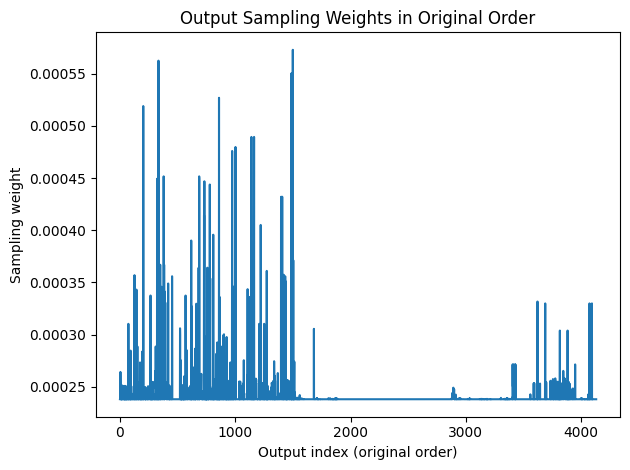

In [9]:
x = np.arange(len(weights))

plt.figure()
plt.plot(x, weights)
plt.xlabel("Output index (original order)")
plt.ylabel("Sampling weight")
plt.title("Output Sampling Weights in Original Order")
plt.tight_layout()
plt.show()

### Selected indices histogram

In [10]:
def load_histogram_txt(path):
    hist = {}
    with open(path, "r") as f:
        for line in f:
            idx, count = line.strip().split(":")
            hist[int(idx)] = int(count)
    return hist

def plot_histogram(hist, title="Selected Indices Distribution", width=1.0):
    indices = list(hist.keys())
    counts = list(hist.values())

    plt.figure(figsize=(16, 6))
    plt.bar(
        indices,
        counts,
        width=width, 
        edgecolor="none",
        linewidth=0,
    )
    plt.xlabel("Index")
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    plt.show()

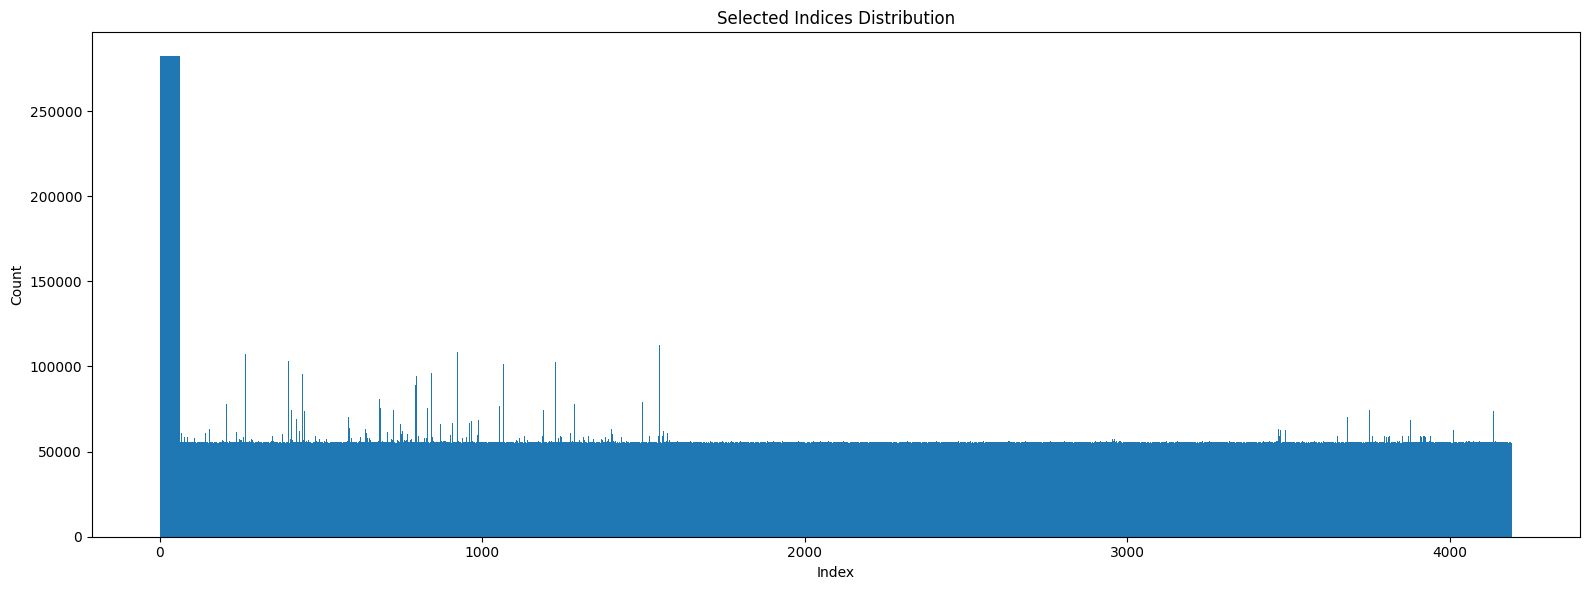

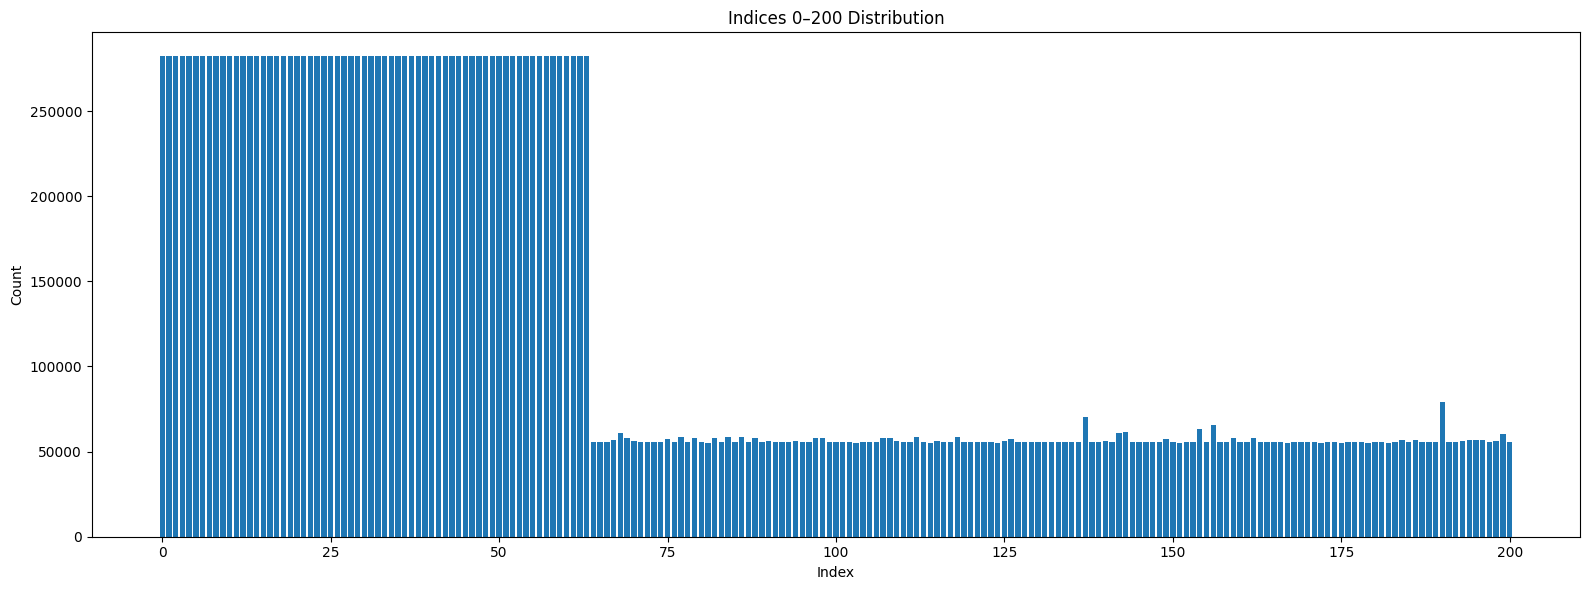

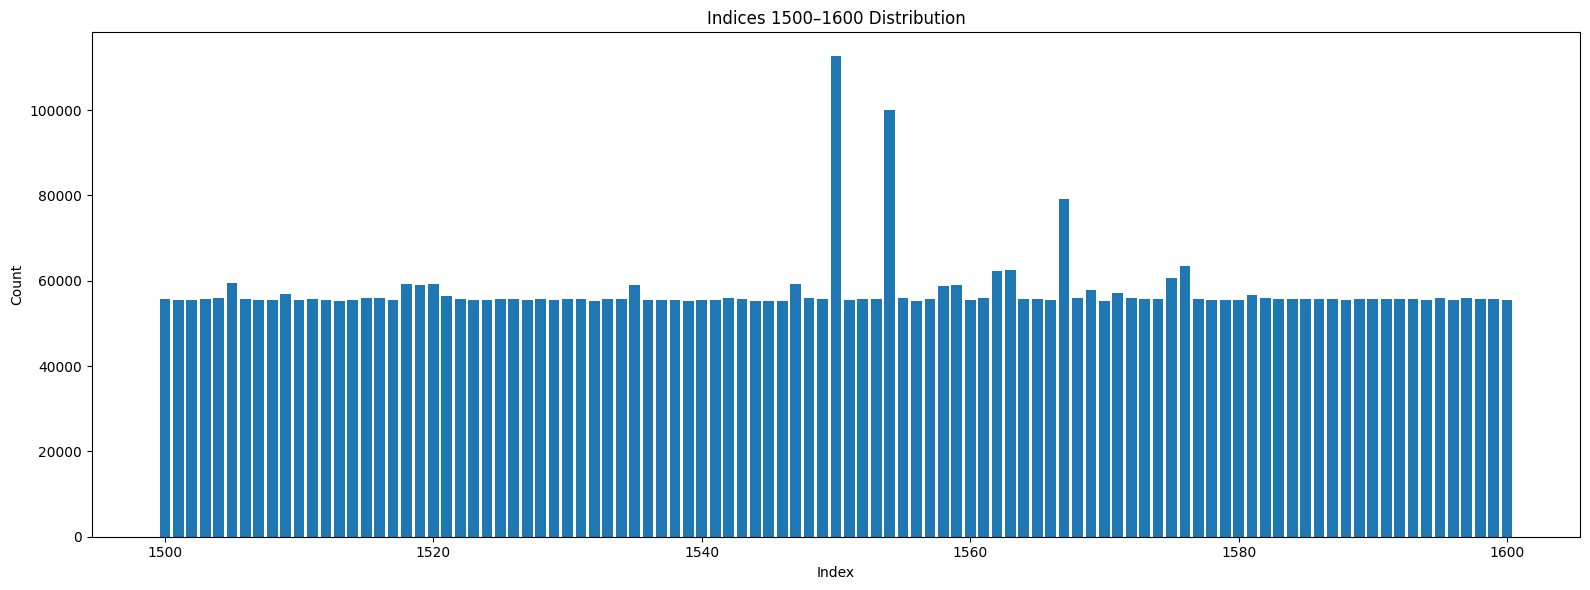

In [11]:
# output subset ratio = 0.2, temperature = 5
hist = load_histogram_txt("selected_indices_histogram.txt")
plot_histogram(hist)

start_index = 0
stop_index = 200

hist_slice1 = {k: v for k, v in hist.items() if start_index <= k <= stop_index}
plot_histogram(hist_slice1, title=f"Indices {start_index}–{stop_index} Distribution", width=0.8)

start_index = 1500
stop_index = 1600

hist_slice2 = {k: v for k, v in hist.items() if start_index <= k <= stop_index}
plot_histogram(hist_slice2, title=f"Indices {start_index}–{stop_index} Distribution", width=0.8)

### Correlation Matrix

In [2]:
def precompute_flux_correlation(
    data_path,
    output_cols,
    device="cpu",
):
    flux_cols = [f"{c}_flux" for c in output_cols]

    df = pd.read_csv(
        data_path,
        usecols=flux_cols,
        dtype=np.float32
    )

    flux_data = df.to_numpy(copy=False)
    flux_centered = flux_data - flux_data.mean(axis=0)

    cov = np.cov(flux_centered, rowvar=False)
    std = np.sqrt(np.diag(cov))
    std_safe = std.copy()
    std_safe[std_safe == 0] = 1.0
    corr = cov / (std_safe[:, None] * std_safe[None, :])
    corr = np.nan_to_num(corr)

    corr_tensor = torch.tensor(corr, device=device)

    print(
        f"Correlation matrix computed: {corr_tensor.shape}, "
        f"min={corr_tensor.min():.3f}, max={corr_tensor.max():.3f}"
    )

    return corr_tensor

In [5]:
DATA_PATH = './data/2025-12-18_yeast9_data_9857_samples.csv'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

corr_tensor = precompute_flux_correlation(
    DATA_PATH,
    outputs,
    device='cpu'
)

Using device: cuda
Correlation matrix computed: torch.Size([4131, 4131]), min=-1.000, max=1.000


In [6]:
def plot_correlation_matrix(
    corr_tensor,
    vmax=1.0,
    downsample=None,
    title="Flux Correlation Matrix",
    save_path=None
):
    """
    Plot a correlation matrix using coolwarm colormap.
    """

    # Move to CPU and convert to numpy
    corr = corr_tensor.detach().float().cpu().numpy()

    if downsample is not None and corr.shape[0] > downsample:
        idx = np.linspace(0, corr.shape[0] - 1, downsample).astype(int)
        corr = corr[np.ix_(idx, idx)]
        title += f" (downsampled to {downsample}×{downsample})"

    plt.figure(figsize=(10, 8))
    im = plt.imshow(
        corr,
        cmap="coolwarm",
        vmin=-vmax,
        vmax=vmax,
        interpolation="nearest"
    )
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title(title)
    plt.xlabel("Flux index")
    plt.ylabel("Flux index")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200)
        plt.close()
    else:
        plt.show()

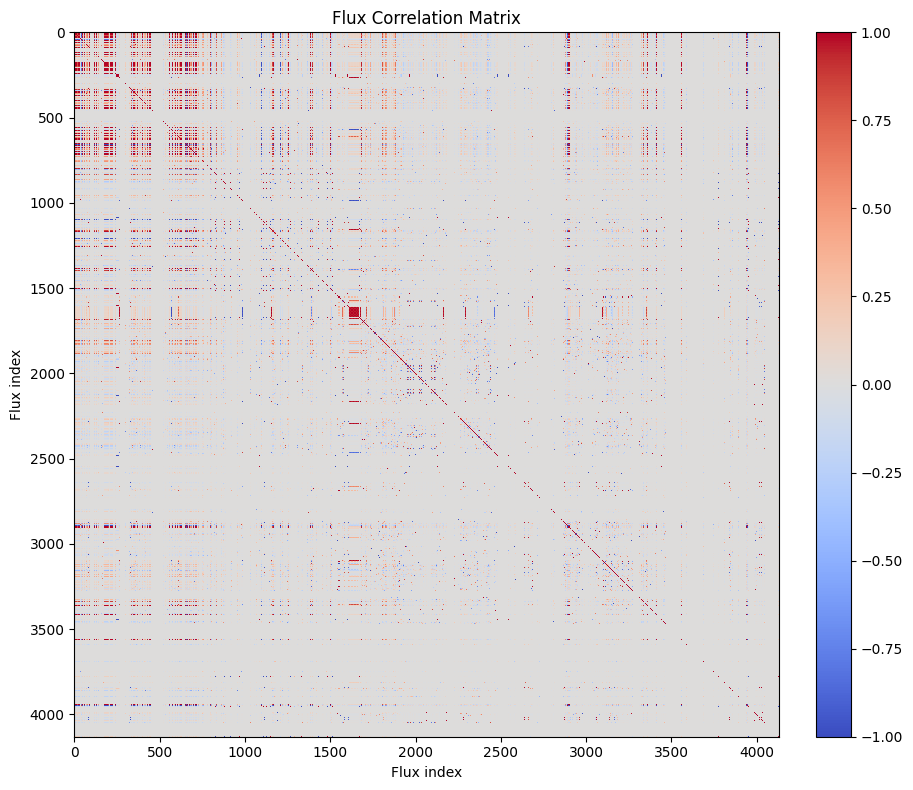

In [18]:
plot_correlation_matrix(corr_tensor)

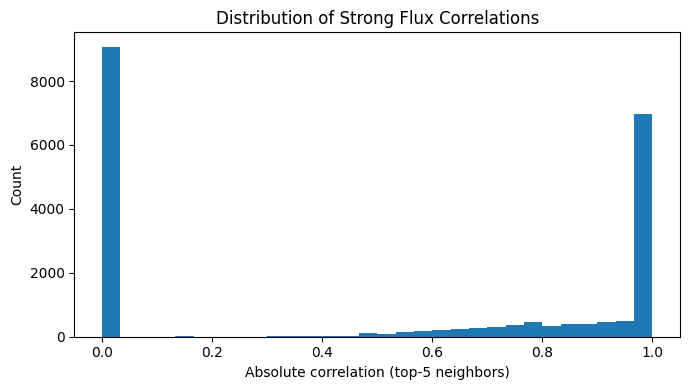

In [19]:
def plot_topk_correlation_histogram(
    corr_matrix,
    k=5,
    bins=30,
    figsize=(7, 4),
):
    """
    Histogram of top-k absolute correlations per flux.
    """
    if hasattr(corr_matrix, "cpu"):
        corr_matrix = corr_matrix.cpu().numpy()

    np.fill_diagonal(corr_matrix, 0.0)

    abs_corr = np.abs(corr_matrix)
    topk_vals = np.sort(abs_corr, axis=1)[:, -k:]
    flattened = topk_vals.flatten()

    plt.figure(figsize=figsize)
    plt.hist(flattened, bins=bins)
    plt.xlabel(f"Absolute correlation (top-{k} neighbors)")
    plt.ylabel("Count")
    plt.title("Distribution of Strong Flux Correlations")
    plt.tight_layout()
    plt.show()

plot_topk_correlation_histogram(
    corr_tensor,
    k=5,
)

In [20]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

def plot_clustered_correlation(
    corr_matrix,
    flux_names=None,
    method="average",
    figsize=(10, 10),
):
    """
    Plot hierarchically clustered correlation matrix.
    """
    if hasattr(corr_matrix, "cpu"):
        corr_matrix = corr_matrix.cpu().numpy()

    # distance = 1 - |corr|
    dist_matrix = 1.0 - np.abs(corr_matrix)
    condensed = squareform(dist_matrix, checks=False)

    linkage_mat = linkage(condensed, method=method)
    order = leaves_list(linkage_mat)

    corr_ord = corr_matrix[order][:, order]

    plt.figure(figsize=figsize)
    im = plt.imshow(
        corr_ord,
        cmap="coolwarm",
        vmin=-1,
        vmax=1
    )
    plt.colorbar(im, fraction=0.046)

    if flux_names is not None:
        names_ord = [flux_names[i] for i in order]
        plt.xticks(range(len(names_ord)), names_ord, rotation=90, fontsize=6)
        plt.yticks(range(len(names_ord)), names_ord, fontsize=6)

    plt.title("Hierarchically Clustered Flux Correlations")
    plt.tight_layout()
    plt.show()

plot_clustered_correlation(
    corr_tensor,
    flux_names=None,
)

MemoryError: Unable to allocate 130. MiB for an array with shape (4131, 4131) and data type float64